In [4]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import random

In [7]:
elo_ratings = {
    "Mexico": 1700, "Croatia": 1800, "Morocco": 1780, "Ecuador": 1650,
    "USA": 1750, "Panama": 1520, "Portugal": 1910, "Ghana": 1600,
    "Canada": 1660, "Honduras": 1450, "Spain": 1950, "Serbia": 1740,
    "Brazil": 2010, "Costa Rica": 1530, "Switzerland": 1800, "Cameroon": 1580,
    "Germany": 1920, "Curacao": 1300, "Ivory Coast": 1650,
    "Netherlands": 1890, "Japan": 1760, "Sweden": 1740, "Tunisia": 1620,
    "Belgium": 1850, "Egypt": 1620, "Iran": 1700, "New Zealand": 1530,
    "Cape Verde": 1450, "Saudi Arabia": 1650, "Uruguay": 1820,
    "France": 1980, "Senegal": 1750, "Iraq": 1550, "Norway": 1760,
    "Argentina": 2050, "Algeria": 1600, "Austria": 1760, "Jordan": 1480,
    "England": 1900, "Colombia": 1790, "Australia": 1650, "Uzbekistan": 1520,
    "South Korea": 1740, "Kenya": 1400, "Qatar": 1530, "Chile": 1680,
    "Benin": 1410, "Venezuela": 1590,
}

groups = {
    "A": ["Mexico", "Ecuador", "Croatia", "Morocco"],
    "B": ["USA", "Panama", "Portugal", "Ghana"],
    "C": ["Canada", "Honduras", "Spain", "Serbia"],
    "D": ["Brazil", "Costa Rica", "Switzerland", "Cameroon"],
    "E": ["Germany", "Curacao", "Ivory Coast", "Chile"],
    "F": ["Netherlands", "Japan", "Sweden", "Tunisia"],
    "G": ["Belgium", "Egypt", "Iran", "New Zealand"],
    "H": ["Spain", "Cape Verde", "Saudi Arabia", "Uruguay"],
    "I": ["France", "Senegal", "Iraq", "Norway"],
    "J": ["Argentina", "Algeria", "Austria", "Jordan"],
    "K": ["England", "Colombia", "Australia", "Uzbekistan"],
    "L": ["Portugal", "South Korea", "Benin", "Venezuela"],
}

print("✅ Teams and ELO ratings loaded!")
print(f"Total teams: {len(elo_ratings)}")

# Verify no team is missing from groups
all_group_teams = [team for teams in groups.values() for team in teams]
print(f"Total team slots in groups: {len(all_group_teams)}")

missing = [t for t in all_group_teams if t not in elo_ratings]
if missing:
    print(f"⚠️ Missing ELO for: {missing}")
else:
    print("✅ All teams have ELO ratings!")

✅ Teams and ELO ratings loaded!
Total teams: 48
Total team slots in groups: 48
✅ All teams have ELO ratings!


In [8]:
def win_probability(elo_a, elo_b):
    """
    Returns the probability that Team A beats Team B.
    Based on the standard ELO formula.
    """
    prob_a = 1 / (1 + 10 ** ((elo_b - elo_a) / 400))
    return prob_a

# Quick test
p = win_probability(elo_ratings["Brazil"], elo_ratings["Germany"])
print(f"Brazil vs Germany — Brazil win probability: {p:.1%}")

Brazil vs Germany — Brazil win probability: 62.7%


In [9]:
def simulate_match(team_a, team_b):

    #Simulates one match. Returns the winner.
    #Uses ELO win probability + adds draw possibility.

    p_a = win_probability(elo_ratings[team_a], elo_ratings[team_b])

    # In football, draws happen ~25% of the time
    # We split the probability space into 3 zones
    p_draw = 0.25
    p_a_adjusted = p_a * (1 - p_draw)
    p_b_adjusted = (1 - p_a) * (1 - p_draw)

    outcome = random.random()

    if outcome < p_a_adjusted:
        return team_a, team_b, "A"       # Team A wins
    elif outcome < p_a_adjusted + p_draw:
        return team_a, team_b, "draw"    # Draw
    else:
        return team_a, team_b, "B"       # Team B wins

# Test it
for _ in range(5):
    a, b, result = simulate_match("France", "Argentina")
    print(f"France vs Argentina → {result}")

France vs Argentina → B
France vs Argentina → draw
France vs Argentina → A
France vs Argentina → A
France vs Argentina → B


In [20]:
def simulate_group(group_teams):
    """
    Simulates all 6 matches in a 4-team group.
    Returns standings sorted by points, then goal diff (simplified).
    """
    standings = {team: {"points": 0, "gd": 0} for team in group_teams}

    # Play every team against every other team (round robin)
    for i in range(len(group_teams)):
        for j in range(i + 1, len(group_teams)):
            team_a = group_teams[i]
            team_b = group_teams[j]
            _, _, result = simulate_match(team_a, team_b)

            if result == "A":
                standings[team_a]["points"] += 3
                standings[team_a]["gd"] += 1
                standings[team_b]["gd"] -= 1
            elif result == "B":
                standings[team_b]["points"] += 3
                standings[team_b]["gd"] += 1
                standings[team_a]["gd"] -= 1
            else:  # draw
                standings[team_a]["points"] += 1
                standings[team_b]["points"] += 1

    # Sort by points, then goal difference
    sorted_teams = sorted(
        standings.items(),
        key=lambda x: (x[1]["points"], x[1]["gd"]),
        reverse=True
    )

    return sorted_teams  # Returns list of (team, stats) tuples

# Test it
result = simulate_group(groups["I"])  # Group I: France, Senegal, Iraq, Norway
print("Group I standings:")
for i, (team, stats) in enumerate(result):
    print(f"  {i+1}. {team} — {stats['points']} pts, GD: {stats['gd']}")

Group I standings:
  1. Senegal — 7 pts, GD: 2
  2. France — 6 pts, GD: 1
  3. Norway — 3 pts, GD: -1
  4. Iraq — 1 pts, GD: -2


In [21]:
def simulate_knockout_match(team_a, team_b):
    """
    In knockouts there are no draws — someone must win.
    If it's close, go to 'penalties' (coin flip weighted by ELO).
    """
    p_a = win_probability(elo_ratings[team_a], elo_ratings[team_b])
    return team_a if random.random() < p_a else team_b


def simulate_tournament():
    """
    Simulates the entire 2026 World Cup once.
    Returns the winner.
    """
    # --- GROUP STAGE ---
    qualifiers = []   # top 2 from each group
    third_places = [] # 3rd place teams + their points

    for group_name, teams in groups.items():
        result = simulate_group(teams)
        qualifiers.append(result[0][0])  # 1st place
        qualifiers.append(result[1][0])  # 2nd place
        third_places.append(result[2])   # 3rd place

    # Best 8 third-place teams also advance (2026 rule)
    third_places_sorted = sorted(
        third_places,
        key=lambda x: (x[1]["points"], x[1]["gd"]),
        reverse=True
    )
    best_third = [team for team, _ in third_places_sorted[:8]]
    round_of_32 = qualifiers + best_third  # 24 + 8 = 32 teams

    # --- KNOCKOUT STAGE ---
    random.shuffle(round_of_32)  # Simplified bracket (random seeding)

    current_round = round_of_32
    round_names = ["Round of 32", "Round of 16", "Quarter-Finals", "Semi-Finals", "Final"]

    for round_name in round_names:
        next_round = []
        for i in range(0, len(current_round), 2):
            winner = simulate_knockout_match(current_round[i], current_round[i+1])
            next_round.append(winner)
        current_round = next_round

    return current_round[0]  # Champion!

# Test one simulation
champion = simulate_tournament()
print(f"🏆 2026 World Cup Winner: {champion}")

🏆 2026 World Cup Winner: Argentina


In [22]:
N_SIMULATIONS = 100_000
results = {}

print(f"Running {N_SIMULATIONS:,} simulations...")

for _ in range(N_SIMULATIONS):
    winner = simulate_tournament()
    results[winner] = results.get(winner, 0) + 1

# Convert to percentages
win_prob = {
    team: count / N_SIMULATIONS * 100
    for team, count in results.items()
}

# Sort by probability
win_prob = dict(sorted(win_prob.items(), key=lambda x: x[1], reverse=True))

print("\n🏆 World Cup 2026 Winner Probabilities:")
print("-" * 35)
for team, prob in list(win_prob.items())[:15]:  # Top 15
    bar = "█" * int(prob)
    print(f"{team:<15} {prob:5.1f}%  {bar}")

Running 100,000 simulations...

🏆 World Cup 2026 Winner Probabilities:
-----------------------------------
Argentina        22.0%  ██████████████████████
Spain            16.2%  ████████████████
Brazil           15.5%  ███████████████
France           11.1%  ███████████
Portugal         10.2%  ██████████
Germany           5.8%  █████
England           4.3%  ████
Netherlands       3.9%  ███
Belgium           2.2%  ██
Uruguay           1.4%  █
Switzerland       1.1%  █
Croatia           1.0%  
Colombia          0.8%  
Morocco           0.6%  
Austria           0.5%  


/tmp/ipykernel_8592/3172596556.py:17: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_8592/3172596556.py:18: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.savefig("wc2026_predictions.png", dpi=150, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


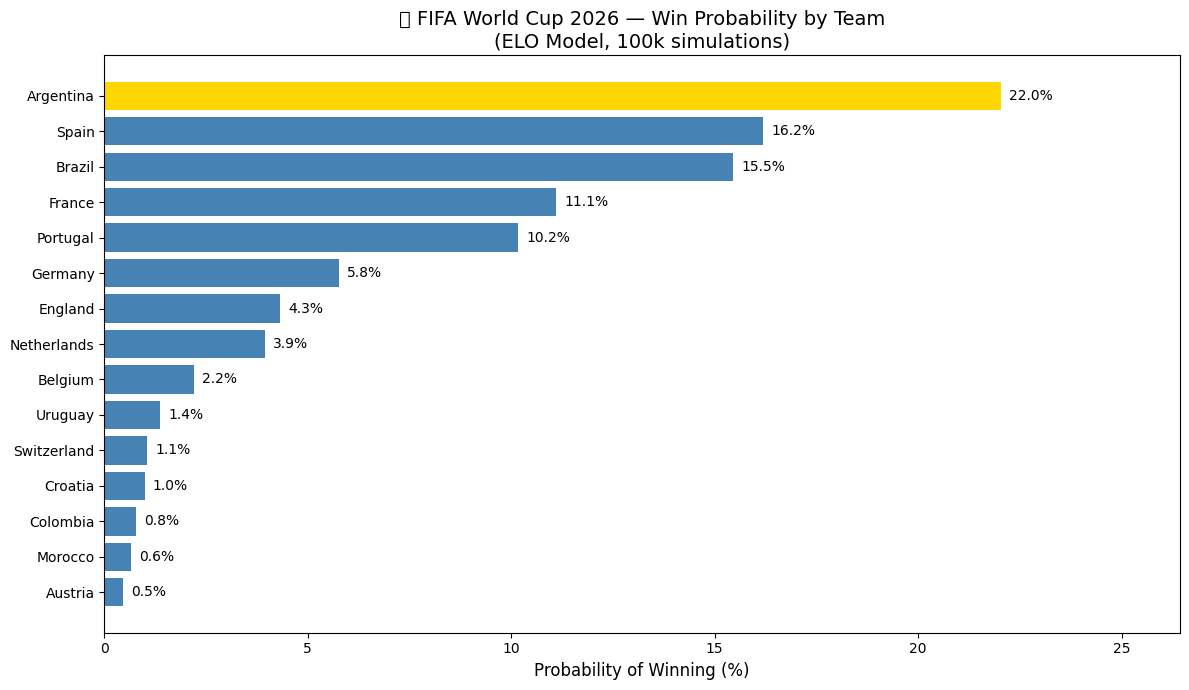

✅ Chart saved!


In [23]:
# Plot top 15 teams
top15 = dict(list(win_prob.items())[:15])

plt.figure(figsize=(12, 7))
colors = ["gold" if i == 0 else "steelblue" for i in range(len(top15))]
bars = plt.barh(list(top15.keys())[::-1], list(top15.values())[::-1], color=colors[::-1])

plt.xlabel("Probability of Winning (%)", fontsize=12)
plt.title("🏆 FIFA World Cup 2026 — Win Probability by Team\n(ELO Model, 100k simulations)", fontsize=14)
plt.xlim(0, max(top15.values()) * 1.2)

# Add percentage labels on bars
for bar, val in zip(bars, list(top15.values())[::-1]):
    plt.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
             f'{val:.1f}%', va='center', fontsize=10)

plt.tight_layout()
plt.savefig("wc2026_predictions.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved!")